In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA

In [23]:
def get_data():    
    mnist_train = datasets.MNIST(root="./data", train=True, download=True)
    mnist_test = datasets.MNIST(root="./data", train=False, download=True)

    # We don't need labels for autoencoders, so we will just use the images as both inputs and targets
    X_train = mnist_train.data.float() / 255.0
    y_train = mnist_train.targets.long()
    X_test = mnist_test.data.float() / 255.0
    y_test = mnist_test.targets.long()

    X = torch.cat([X_train, X_test], dim=0)
    y = torch.cat([y_train, y_test], dim=0)

    return X, y

In [15]:
class MNIST_Autoencoder(nn.Module):
    def __init__(self, encoding_dim=250, bottleneck_dim=50):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, encoding_dim),
            nn.ReLU(),
            nn.Linear(encoding_dim, bottleneck_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, encoding_dim),
            nn.ReLU(),
            nn.Linear(encoding_dim, 28*28)
        )

    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # flatten the image, keep the batch dimension
        x = self.encoder(x)
        x = F.relu(x) # we can also add a non-linearity after the bottleneck if we want, but it's not strictly necessary
        x = self.decoder(x)
        x = torch.sigmoid(x) # we use sigmoid to get outputs between 0 and 1, since the input images are normalized to [0, 1]
        return x 
    
# By using np.random.choice(..., replace=False) inside every iteration of the loop, we're treating the dataset as a giant pool where any image
#  could appear in any update step. This is a more "pure" form of stochastic sampling, even if it means some images might be seen twice in an 
# "epoch" and others not at all.

# The Advantage: If you have a massive dataset, you might not want to wait for a full "epoch" to finish. Manual sampling allows you to simply say,
#  "Train for 50,000 steps," without worrying about where an epoch starts or ends. It turns training into a continuous stream.

def train_autoencoder(model, X, optimizer, loss_fn, epochs):
    
    losses = np.zeros(epochs)

    for epoch in range(epochs):
        model.train()

        # select a random batch of images
        randomidx = np.random.choice(X.shape[0], size=32, replace=False) # random minibatch of 32 images
        X_batch = X[randomidx]

        output = model(X_batch)
        loss = loss_fn(output, X_batch.flatten(start_dim=1)) # we use the same images as both inputs and targets

        # backpropagation and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # losses in this epoch
        losses[epoch] = loss.item()

    return losses

In [ ]:
learning_rate = 1e-3
epochs = 10000 # we set a lot of epochs since we are using small minibatches inside the training loop, so it is not so expensive in reality

model = MNIST_Autoencoder(encoding_dim=150, bottleneck_dim=15)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

X, y = get_data()
losses = train_autoencoder(model, X, optimizer, loss_fn, epochs)

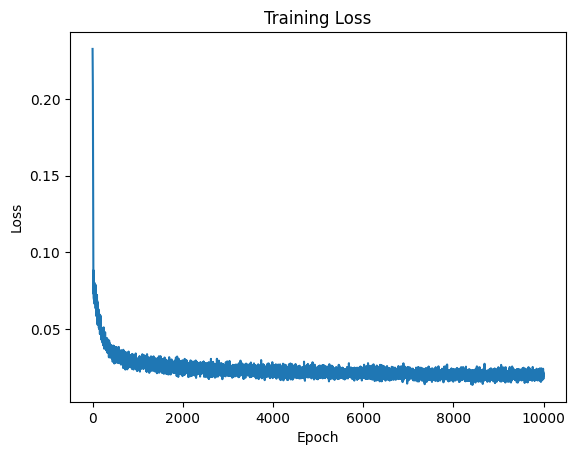

In [17]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

Original data shape: torch.Size([70000, 28, 28])
Reconstructed data shape: (70000, 784)
Latent representation shape: (70000, 15)


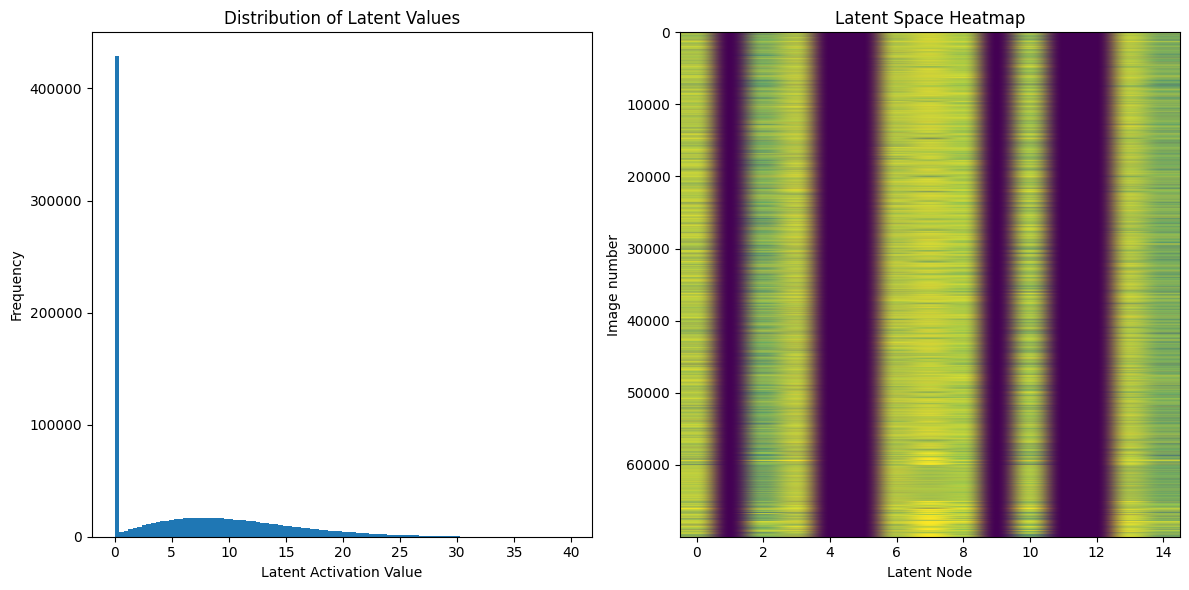

In [ ]:
y_pred = model(X).detach().numpy()

# we use relu on the latent space to see the activations more clearly, since many of them might be negative and close to zero, 
# which can make it harder to visualize patterns in the latent space
y_latent = F.relu(model.encoder(torch.flatten(X, start_dim=1)).detach()).numpy()

# print sizes
print("Original data shape:", X.shape)
print("Reconstructed data shape:", y_pred.shape)
print("Latent representation shape:", y_latent.shape)

# what does the latent space look like?
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].hist(y_latent.flatten(), 100)
ax[0].set_title("Distribution of Latent Values")
ax[0].set_xlabel("Latent Activation Value")
ax[0].set_ylabel("Frequency")

ax[1].imshow(y_latent, aspect="auto", vmin=0, vmax=10)
ax[1].set_title("Latent Space Heatmap")
ax[1].set_xlabel("Latent Node")
ax[1].set_ylabel("Image number")

plt.tight_layout()
plt.show()

In [ ]:
# we can see that even the latent space has 15 dimensions, most of the values are close to zero, and only a few nodes have significant activations 
# for each image. This suggests that the autoencoder has learned to compress the information into a sparse representation, where only a few latent 
# nodes are active for any given input image.

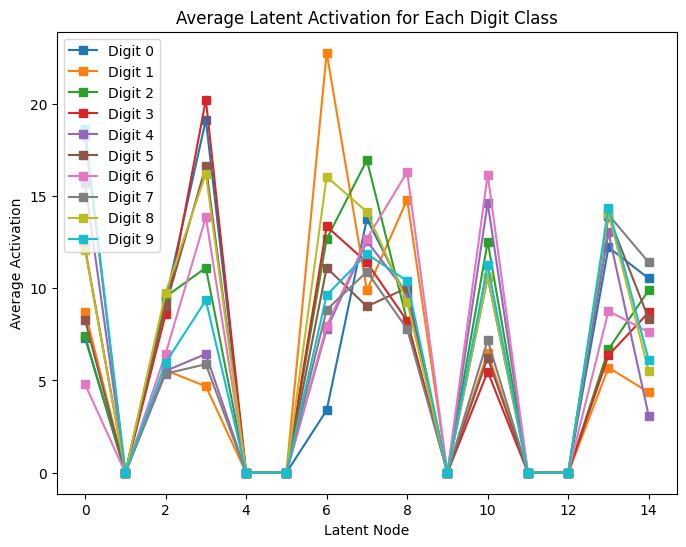

In [ ]:
# compute the average latent representation for each digit class
sourcecode = np.zeros((y_latent.shape[1], 10)) # 15 latent nodes, 10 digit classes

for i in range(10):
    digidx = np.where(y == i)
    sourcecode[:, i] = y_latent[digidx].mean(axis=0)

fig = plt.figure(figsize=(8, 6))
plt.plot(sourcecode, "s-")
plt.xlabel("Latent Node")
plt.ylabel("Average Activation")
plt.title("Average Latent Activation for Each Digit Class")
plt.legend([f"Digit {i}" for i in range(10)])

# we can see, units 1, 4, 5, 9,  11 and 12 are nearly never active,
# while units 0, 2, 3, 6, 7, 8, 10, 13 and 14 have more significant activations for certain digit classes.
# This means, in theory this is 15dimensional latent space, but in practice only about 9 of those dimensions
# are really being used to encode the information about the digits.

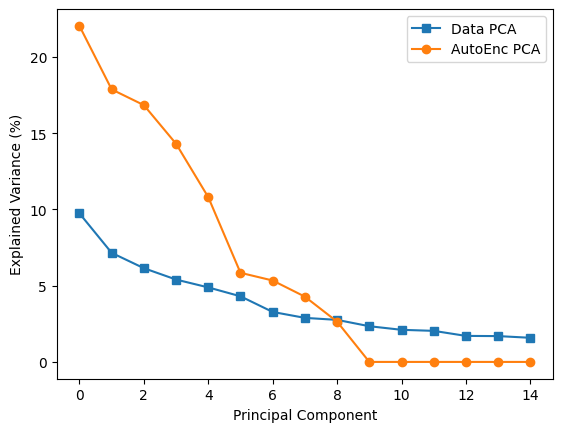

In [ ]:
# explore the reduced compressed space with PCA
pca_data = PCA(n_components=15).fit(X.flatten(start_dim=1).numpy())
pca_code = PCA(               ).fit(y_latent) # it is already 15-dimensional, so we don't need to reduce it further

plt.plot(100*pca_data.explained_variance_ratio_, "s-", label="Data PCA")
plt.plot(100*pca_code.explained_variance_ratio_, "o-", label="AutoEnc PCA")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.legend()
plt.show()

# we can see that PCA has a lower decay in explained variance across components compared to the autoencoder's latent space, 
# which suggests that the autoencoder has learned a more efficient representation of the data, where most of the variance 
# is captured in fewer dimensions.

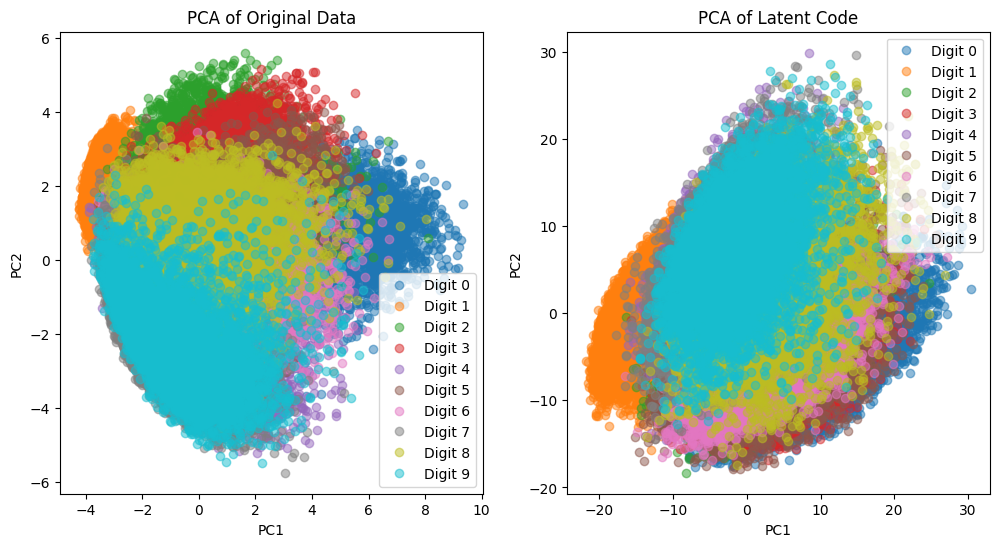

In [ ]:
# compute the projection of the data onto the 2 main PCA components for both the original data and the latent code

scores_data = pca_data.fit_transform(X.flatten(start_dim=1).numpy())
scores_code = pca_code.fit_transform(y_latent)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

for label in range(10):
    ax[0].plot(scores_data[y == label, 0], scores_data[y == label, 1], "o", label=f"Digit {label}", alpha=0.5)
    ax[0].set_xlabel("PC1")
    ax[0].set_ylabel("PC2")
    ax[0].legend()
    ax[0].set_title("PCA of Original Data")

    ax[1].plot(scores_code[y == label, 0], scores_code[y == label, 1], "o", label=f"Digit {label}", alpha=0.5)
    ax[1].set_xlabel("PC1")
    ax[1].set_ylabel("PC2")
    ax[1].legend()
    ax[1].set_title("PCA of Latent Code")

plt.show()